In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
close=pd.read_csv('sp500_close.csv',index_col=0, parse_dates=True)

In [8]:
goog=close[['GOOG']].copy().dropna()

In [10]:
goog.head()

,GOOG
2014-03-27,558.46
2014-03-28,559.99
2014-03-31,556.97
2014-04-01,567.16
2014-04-02,567.00


<AxesSubplot:>

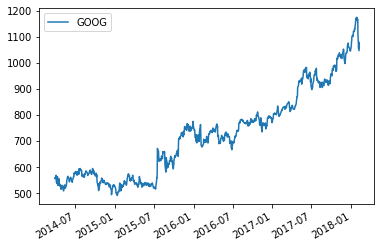

In [11]:
goog.plot()

In [12]:
goog_ret=np.log(goog.pct_change(1)+1)

<AxesSubplot:>

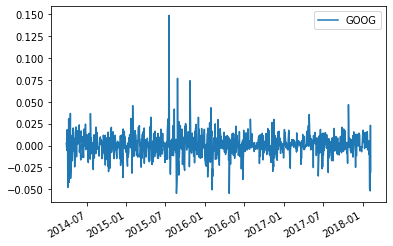

In [13]:
goog_ret.plot()

In [25]:
goog['SMA-10']=goog['GOOG'].rolling(10).mean()
goog.head(20)

,GOOG,SMA-10,SMA-50
2014-03-27,558.46,NaN,NaN
2014-03-28,559.99,NaN,NaN
2014-03-31,556.97,NaN,NaN
2014-04-01,567.16,NaN,NaN
2014-04-02,567.00,NaN,NaN
2014-04-03,569.74,NaN,NaN
2014-04-04,543.14,NaN,NaN
2014-04-07,538.15,NaN,NaN
2014-04-08,554.90,NaN,NaN
2014-04-09,564.14,557.965,NaN


In [26]:
type(goog['GOOG'].rolling(10))

pandas.core.window.rolling.Rolling

<AxesSubplot:>

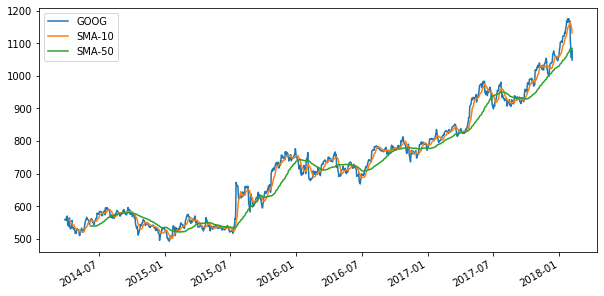

In [27]:
goog.plot(figsize=(10,5))

<AxesSubplot:>

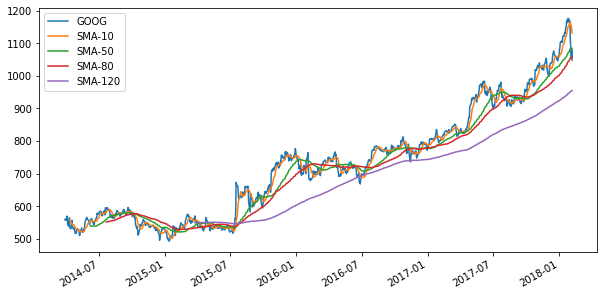

In [62]:
goog['SMA-50']=goog['GOOG'].rolling(50).mean()
goog['SMA-80']=goog['GOOG'].rolling(80).mean()
goog['SMA-120']=goog['GOOG'].rolling(250).mean()


goog.plot(figsize=(10,5))

In [54]:
goog_aapl=close[['GOOG','AAPL']].copy().dropna()
cov=goog_aapl.rolling(50).cov()
cov

GOOG       AAPL
2014-03-27 GOOG          NaN        NaN
           AAPL          NaN        NaN
2014-03-28 GOOG          NaN        NaN
           AAPL          NaN        NaN
2014-03-31 GOOG          NaN        NaN
...                      ...        ...
2018-02-05 AAPL    34.825709  17.568865
2018-02-06 GOOG  2691.756465  38.174468
           AAPL    38.174468  19.121371
2018-02-07 GOOG  2678.778214  49.980378
           AAPL    49.980378  22.052882

[1950 rows x 2 columns]

In [30]:
cov.loc['2018-02-07'].to_numpy()

array([[2678.77821424,   49.98037849],
       [  49.98037849,   22.05288249]])

In [37]:
goog_aapl_ret=np.log(1+goog_aapl.pct_change(1))
goog_aapl_ret.head()
                     

,GOOG,AAPL
2014-03-27,NaN,NaN
2014-03-28,0.002736,-0.001117
2014-03-31,-0.005408,-0.000223
2014-04-01,0.018130,0.009106
2014-04-02,-0.000282,0.001661


In [75]:
goog_aapl_ret['GOOG-SMA-50']=goog_aapl_ret['GOOG'].rolling(50).mean()
goog_aapl_ret['AAPL-SMA-50']=goog_aapl_ret['AAPL'].rolling(50).mean()

<AxesSubplot:>

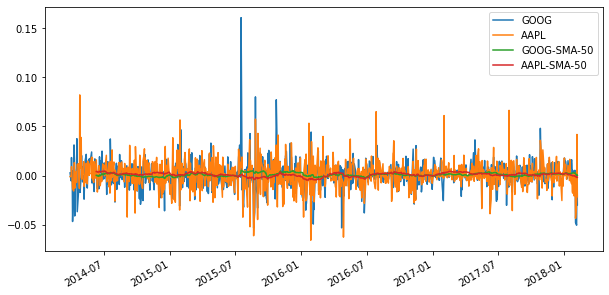

In [79]:
goog_aapl_ret.plot(figsize=(10,5))

In [77]:
cov=goog_aapl_ret[['GOOG-SMA-50','AAPL-SMA-50']].rolling(50).cov()
cov.tail()

GOOG-SMA-50   AAPL-SMA-50
2018-02-05 AAPL-SMA-50 -7.578159e-08  1.199753e-06
2018-02-06 GOOG-SMA-50  2.786908e-07 -2.017999e-08
           AAPL-SMA-50 -2.017999e-08  1.338227e-06
2018-02-07 GOOG-SMA-50  3.332155e-07  7.703940e-08
           AAPL-SMA-50  7.703940e-08  1.511571e-06

In [78]:
corr=goog_aapl_ret[['GOOG-SMA-50','AAPL-SMA-50']].rolling(50).corr()
corr.tail(16)

GOOG-SMA-50  AAPL-SMA-50
2018-01-29 GOOG-SMA-50     1.000000    -0.340574
           AAPL-SMA-50    -0.340574     1.000000
2018-01-30 GOOG-SMA-50     1.000000    -0.385195
           AAPL-SMA-50    -0.385195     1.000000
2018-01-31 GOOG-SMA-50     1.000000    -0.414124
           AAPL-SMA-50    -0.414124     1.000000
2018-02-01 GOOG-SMA-50     1.000000    -0.450542
           AAPL-SMA-50    -0.450542     1.000000
2018-02-02 GOOG-SMA-50     1.000000    -0.397458
           AAPL-SMA-50    -0.397458     1.000000
2018-02-05 GOOG-SMA-50     1.000000    -0.136585
           AAPL-SMA-50    -0.136585     1.000000
2018-02-06 GOOG-SMA-50     1.000000    -0.033044
           AAPL-SMA-50    -0.033044     1.000000
2018-02-07 GOOG-SMA-50     1.000000     0.108552
           AAPL-SMA-50     0.108552     1.000000

EWMA

In [4]:
df=pd.read_csv('airline_passengers.csv',index_col='Month',parse_dates=True)

In [94]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [95]:
df.isna().sum()

Passengers    0
dtype: int64

<AxesSubplot:xlabel='Month'>

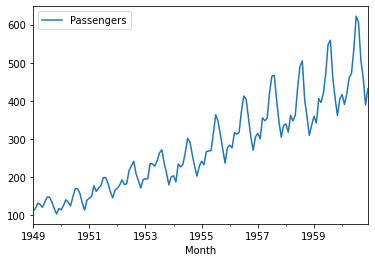

In [96]:
df.plot()

In [107]:
alpha=.2

In [98]:
df['EWMA']=df['Passengers'].ewm(alpha=alpha,adjust=False).mean()

In [99]:
type(df['Passengers'].ewm(alpha=alpha,adjust=False))

pandas.core.window.ewm.ExponentialMovingWindow

<AxesSubplot:xlabel='Month'>

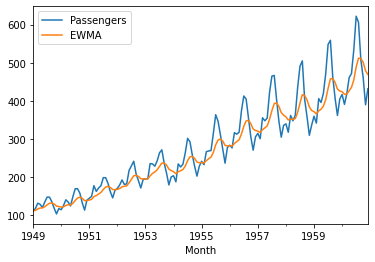

In [100]:
df.plot()

In [110]:
manual_ewma=[]
for x in df['Passengers'].to_numpy():
    if len(manual_ewma)>0:
        xhat=alpha * x+(1-alpha)*manual_ewma[-1]
    else:
        xhat=x
    manual_ewma.append(xhat)
df['Manual']=manual_ewma
        

<AxesSubplot:xlabel='Month'>

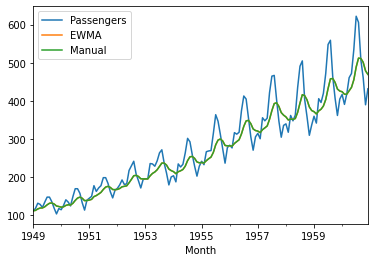

In [111]:
df.plot()

In [112]:
df.head()

,Passengers,EWMA,Manual
Month,,,
1949-01-01,112,112.0000,112.0000
1949-02-01,118,113.2000,113.2000
1949-03-01,132,116.9600,116.9600
1949-04-01,129,119.3680,119.3680
1949-05-01,121,119.6944,119.6944


In [113]:
df.drop('Manual',axis=1,inplace=True)

In [121]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [122]:
ses=SimpleExpSmoothing(df['Passengers'])

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [123]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [125]:
df.index.freq='MS'

In [126]:
ses=SimpleExpSmoothing(df['Passengers'],initialization_method='legacy-heuristic')

In [127]:
res=ses.fit(smoothing_level=alpha,optimized=False)

In [128]:
res

In [129]:
res.predict(start=df.index[0],end=df.index[-1])

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    113.200000
1949-04-01    116.960000
1949-05-01    119.368000
                 ...    
1960-08-01    488.767616
1960-09-01    512.214093
1960-10-01    511.371274
1960-11-01    501.297019
1960-12-01    479.037615
Freq: MS, Length: 144, dtype: float64

In [132]:
df['SES']=res.predict(start=df.index[0],end=df.index[-1])

In [133]:
np.allclose(df['SES'],res.fittedvalues)

True

<AxesSubplot:xlabel='Month'>

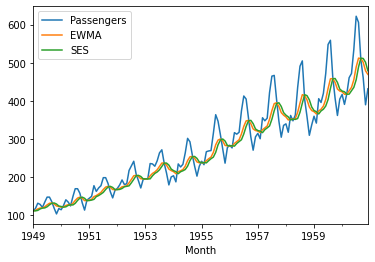

In [134]:
df.plot()

In [135]:
df.head()

,Passengers,EWMA,SES
Month,,,
1949-01-01,112,112.0000,112.000
1949-02-01,118,113.2000,112.000
1949-03-01,132,116.9600,113.200
1949-04-01,129,119.3680,116.960
1949-05-01,121,119.6944,119.368


In [136]:
df['SES-1']=df['SES'].shift(-1)

<AxesSubplot:xlabel='Month'>

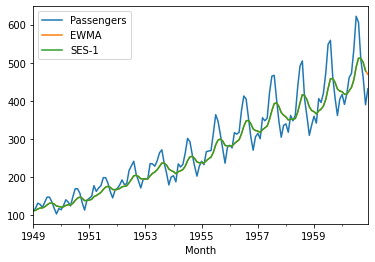

In [137]:
df[['Passengers','EWMA','SES-1']].plot()

In [138]:
N_test=12
train=df.iloc[:-N_test]
test=df.iloc[-N_test:]

In [139]:
ses=SimpleExpSmoothing(train['Passengers'],initialization_method='legacy-heuristic')
res=ses.fit()

In [140]:
train_idx=df.index <= train.index[-1]
test_idx=df.index > train.index[-1]

<AxesSubplot:xlabel='Month'>

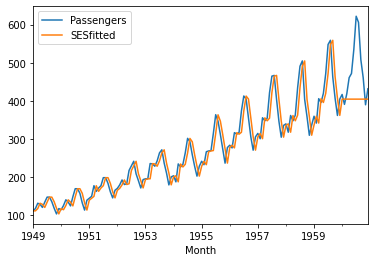

In [141]:
df.loc[train_idx,'SESfitted']=res.fittedvalues
df.loc[test_idx,'SESfitted']=res.forecast(N_test)
df[['Passengers','SESfitted']].plot()

In [142]:
res.params

{'smoothing_level': 0.995,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.0,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

Holt

In [27]:
from statsmodels.tsa.holtwinters import Holt

In [28]:
holt=Holt(df['Passengers'],initialization_method='legacy-heuristic')

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [41]:
res_h=holt.fit()

In [42]:
df['Holt']=res_h.fittedvalues

<AxesSubplot:xlabel='Month'>

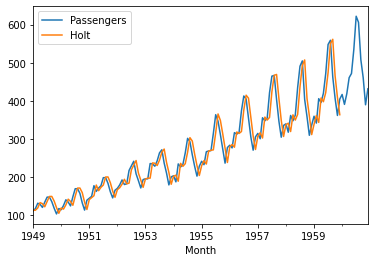

In [43]:
df[['Passengers','Holt']].plot()

<AxesSubplot:xlabel='Month'>

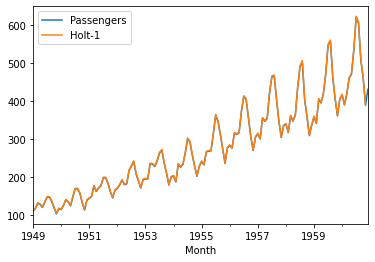

In [11]:
###NO!
df['Holt-1']=df['Holt'].shift(-1)
df[['Passengers','Holt-1']].plot()

In [45]:
N_test=12
train=df.iloc[:-N_test]
test=df.iloc[-N_test:]

In [46]:
train_idx=df.index <= train.index[-1]
test_idx=df.index > train.index[-1]

In [50]:
holt=Holt(train['Passengers'],initialization_method='legacy-heuristic')
res_h=holt.fit()
df.loc[train_idx,'Holt']=res_h.fittedvalues

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [51]:
df.loc[test_idx,'Holt']=res_h.forecast(N_test)

<AxesSubplot:xlabel='Month'>

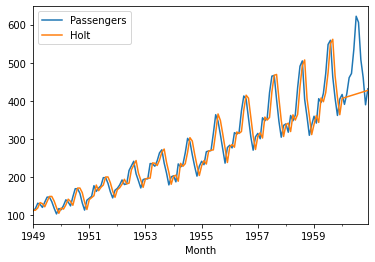

In [52]:
df[['Passengers','Holt']].plot()

Seasonality

In [53]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [64]:
hw=ExponentialSmoothing(train['Passengers'],initialization_method='legacy-heuristic',
                        trend='add',seasonal='add',seasonal_periods=12)
res_hw=hw.fit()

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [70]:
df.loc[train_idx,'HoltWintters']=res_hw.fittedvalues
df.loc[test_idx,'HoltWintters']=res_hw.forecast(N_test)

<AxesSubplot:xlabel='Month'>

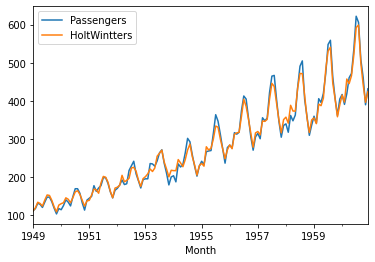

In [71]:
df[['Passengers','HoltWintters']].plot()

In [76]:
def rmse(y,t):
    return np.sqrt(np.mean((y-t)**2))

In [77]:
def mae(y,t):
    return np.mean(np.abs(y-t))
    

In [78]:
print('Train RMSE:',rmse(train['Passengers'],res_hw.fittedvalues))
print('Test RMSE:',rmse(test['Passengers'],res_hw.forecast(N_test)))

Train RMSE: 11.624714430673352
Test RMSE: 16.978029847029934


In [80]:
print('Train MAE:',mae(train['Passengers'],res_hw.fittedvalues))
print('Test MAE:',mae(test['Passengers'],res_hw.forecast(N_test)))

Train MAE: 9.006650631052384
Test MAE: 13.37759090303536


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<AxesSubplot:xlabel='Month'>

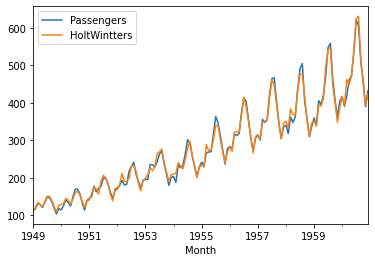

In [82]:
hw=ExponentialSmoothing(train['Passengers'],initialization_method='legacy-heuristic',
                        trend='add',seasonal='mul',seasonal_periods=12)
res_hw=hw.fit()

df.loc[train_idx,'HoltWintters']=res_hw.fittedvalues
df.loc[test_idx,'HoltWintters']=res_hw.forecast(N_test)
df[['Passengers','HoltWintters']].plot()

In [83]:
print('Train RMSE:',rmse(train['Passengers'],res_hw.fittedvalues))
print('Test RMSE:',rmse(test['Passengers'],res_hw.forecast(N_test)))

Train RMSE: 9.767995205168011
Test RMSE: 15.810870232569963


In [84]:
print('Train MAE:',mae(train['Passengers'],res_hw.fittedvalues))
print('Test MAE:',mae(test['Passengers'],res_hw.forecast(N_test)))

Train MAE: 7.604272329965027
Test MAE: 10.30368288348438


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


<AxesSubplot:xlabel='Month'>

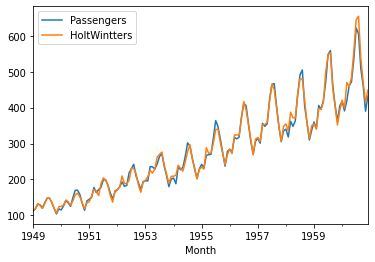

In [85]:
hw=ExponentialSmoothing(train['Passengers'],initialization_method='legacy-heuristic',
                        trend='mul',seasonal='mul',seasonal_periods=12)
res_hw=hw.fit()

df.loc[train_idx,'HoltWintters']=res_hw.fittedvalues
df.loc[test_idx,'HoltWintters']=res_hw.forecast(N_test)
df[['Passengers','HoltWintters']].plot()

In [86]:
print('Train RMSE:',rmse(train['Passengers'],res_hw.fittedvalues))
print('Test RMSE:',rmse(test['Passengers'],res_hw.forecast(N_test)))

Train RMSE: 9.61792487803932
Test RMSE: 25.80687515735493


In [87]:
print('Train MAE:',mae(train['Passengers'],res_hw.fittedvalues))
print('Test MAE:',mae(test['Passengers'],res_hw.forecast(N_test)))

Train MAE: 7.112379992634933
Test MAE: 20.844988412204554


Walk-Forward

In [20]:
import itertools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

In [21]:
df.index.freq='MS'

In [22]:
df.shape

(144, 1)

In [23]:
h=12
step=10
Ntest=len(df)-h-step+1


In [24]:
trend_type_list =['add','mul']
seasonal_type_list=['add','mul']
damped_trend_list=[True,False]
init_method_list=['estimated','heuristic','legacy-heuristic']
use_boxcox_list=[True,False,0]

In [26]:
def walkforward(
    trend_type,
    seasonal_type,
    damped_trend,
    init_method,
    use_boxcox,
    debug=False):
    errors=[]
    seen_last=False
    steps_completed=0
    
    for end_of_train in range(Ntest,len(df)-h+1):
        train=df.iloc[:end_of_train]
        test=df.iloc[end_of_train:end_of_train+h]
    
        if test.index[-1]==df.index[-1]:
            seen_last=True
        
        steps_completed +=1
    
        hw=ExponentialSmoothing(
            train['Passengers'],
            initialization_method=init_method,
            trend=trend_type,
            seasonal=seasonal_type,
            seasonal_periods=12,
            use_boxcox=use_boxcox
        )
        res_hw=hw.fit()
        fcast=res_hw.forecast(h)
        error=mean_squared_error(test['Passengers'],fcast)
        errors.append(error)


    if debug:
        print("seen_last:", seen_last)
        print('steps completed:',steps_completed)
        
    return np.mean(errors)

In [27]:
walkforward('add','add',False,'legacy-heuristic',0,debug=True)

seen_last: True
steps completed: 10


2521.0271721807176

In [28]:
tuple_of_option_lists=(
    trend_type_list,
    seasonal_type_list,
    damped_trend_list,
    init_method_list,
    use_boxcox_list
)

for x in itertools.product(*tuple_of_option_lists):
    print(x)

('add', 'add', True, 'estimated', True)
('add', 'add', True, 'estimated', False)
('add', 'add', True, 'estimated', 0)
('add', 'add', True, 'heuristic', True)
('add', 'add', True, 'heuristic', False)
('add', 'add', True, 'heuristic', 0)
('add', 'add', True, 'legacy-heuristic', True)
('add', 'add', True, 'legacy-heuristic', False)
('add', 'add', True, 'legacy-heuristic', 0)
('add', 'add', False, 'estimated', True)
('add', 'add', False, 'estimated', False)
('add', 'add', False, 'estimated', 0)
('add', 'add', False, 'heuristic', True)
('add', 'add', False, 'heuristic', False)
('add', 'add', False, 'heuristic', 0)
('add', 'add', False, 'legacy-heuristic', True)
('add', 'add', False, 'legacy-heuristic', False)
('add', 'add', False, 'legacy-heuristic', 0)
('add', 'mul', True, 'estimated', True)
('add', 'mul', True, 'estimated', False)
('add', 'mul', True, 'estimated', 0)
('add', 'mul', True, 'heuristic', True)
('add', 'mul', True, 'heuristic', False)
('add', 'mul', True, 'heuristic', 0)
('add

In [30]:
best_score=float('inf')
best_options=None
for x in itertools.product(*tuple_of_option_lists):
    score=walkforward(*x)
    if score <best_score:
        print("Best score so far:", score)
        best_score=score
        best_options=x




Best score so far: 320.66411466530855


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwin

Best score so far: 305.65933493126124


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwinters\model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\holtwin

In [31]:
print('best_score:', best_score)

trend_type,seasonal_type,damped_trend, init_method,use_boxcox=best_options
print("trend_type",trend_type)
print("seasonal_type", seasonal_type)
print("damped_trend", damped_trend)
print("init_method",init_method)
print("use_boxcox",use_boxcox)

best_score: 305.65933493126124
trend_type mul
seasonal_type add
damped_trend True
init_method estimated
use_boxcox False


Sales Data

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import itertools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score

In [49]:
df=pd.read_csv('perrin-freres-monthly-champagne.csv',index_col='Month').dropna().rename({'Perrin Freres monthly champagne sales millions ?64-?72':'Sales'},axis=1)

<AxesSubplot:xlabel='Month'>

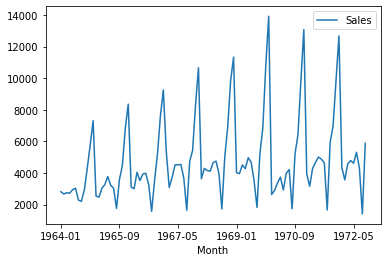

In [50]:
df.plot()

In [51]:
Ntest=12
train=df[:-Ntest]
test=df[-Ntest:]

In [52]:
train_idx=df.index<=train.index[-1]
test_idx=df.index>train.index[-1]

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<AxesSubplot:xlabel='Month'>

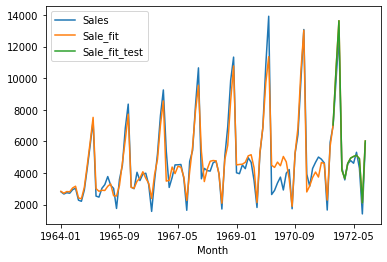

In [54]:
hw=ExponentialSmoothing(train['Sales'],initialization_method='legacy-heuristic',trend='add',seasonal='add',seasonal_periods=12)
res_hw=hw.fit()
df.loc[train_idx,'Sale_fit']=res_hw.fittedvalues
df.loc[test_idx,'Sale_fit_test']=res_hw.forecast(Ntest)
df[['Sales','Sale_fit','Sale_fit_test']].plot()

In [57]:
r2_score(train,res_hw.fittedvalues)

0.9173433418354158

In [58]:
r2_score(test,res_hw.forecast(Ntest))

0.9735679986862097

Stock prediction

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import itertools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import r2_score

In [67]:
df=pd.read_csv('sp500sub.csv',index_col='Date',parse_dates=True)

In [68]:
df

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.220000,9.510000,9.170000,9.500000,9.500000,1865400.0,INCY
2010-01-05,9.510000,10.290000,9.450000,10.270000,10.270000,7608900.0,INCY
2010-01-06,10.380000,11.090000,10.350000,11.000000,11.000000,8046700.0,INCY
2010-01-07,11.000000,11.060000,10.620000,10.820000,10.820000,3680300.0,INCY
2010-01-08,10.820000,11.000000,10.750000,10.940000,10.940000,1529300.0,INCY
...,...,...,...,...,...,...,...
2018-12-21,41.000000,41.900002,40.369999,40.680000,39.367714,17481400.0,MDLZ
2018-12-24,40.720001,40.849998,39.200001,39.480000,38.206425,6641300.0,MDLZ
2018-12-26,39.619999,40.029999,38.779999,40.000000,38.709652,8640100.0,MDLZ


In [116]:
goog=df.query('Name=="GOOG"')[['Close']]

<AxesSubplot:xlabel='Date'>

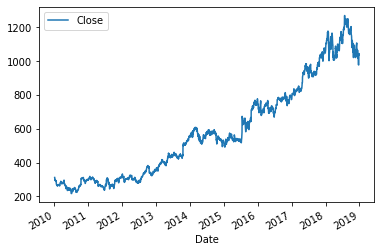

In [117]:
goog.plot()

In [118]:
Ntest=12
train=goog[:-Ntest]
test=goog[-Ntest:]
train_idx=goog.index<=train.index[-1]
test_idx=goog.index>train.index[-1]

In [119]:
hw=ExponentialSmoothing(train,initialization_method='legacy-heuristic',trend='mul')

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


<AxesSubplot:xlabel='Date'>

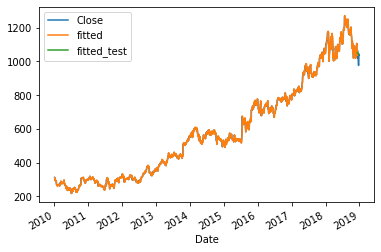

In [125]:
res_hw=hw.fit()
goog.loc[train_idx,'fitted']=res_hw.fittedvalues
goog.loc[test_idx,'fitted_test']=res_hw.forecast(Ntest).to_numpy()

goog.plot()

<AxesSubplot:xlabel='Date'>

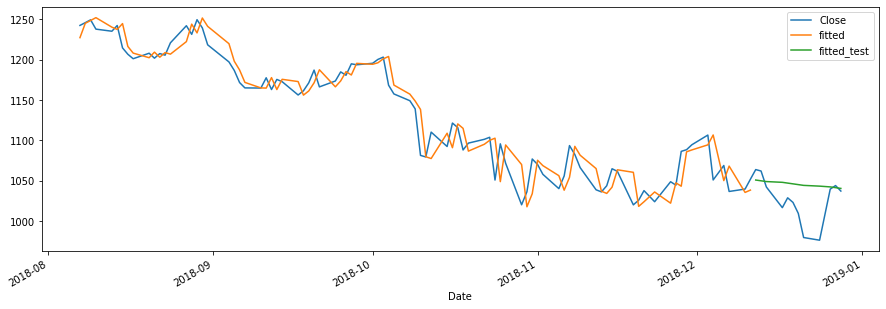

In [129]:
goog[-100:].plot(figsize=(15,5))

In [127]:
r2_score(train,res_hw.fittedvalues)

0.9988615268119774

In [128]:
r2_score(test,res_hw.forecast(Ntest))

c:\Users\4623\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


-0.41278934338522877